<a href="https://colab.research.google.com/github/thomwblair/SatisfactoryMods/blob/main/thomwblair/Stocks/Main/Backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# CELL 1: SETUP & CONFIGURATION
# Installs necessary external libraries, maps imports, and authorizes API keys.
# ==============================================================================

# --- 1. Library Installation --------------------------------------------------
# Added seaborn directly to the core installation payload to support parameter heatmaps cleanly.
!pip install alpaca-py pandas pytz python-dotenv matplotlib seaborn --quiet

# --- 2. Standard System Imports ----------------------------------------------
import os
import json
import time
from datetime import datetime, timedelta, timezone
import pytz
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata
from IPython.display import clear_output

# --- 3. Alpaca Core Imports ---------------------------------------------------
from alpaca.trading.client import TradingClient
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from alpaca.trading.requests import (
    MarketOrderRequest,
    LimitOrderRequest,
    TakeProfitRequest,
    StopLossRequest
)
from alpaca.trading.enums import OrderSide, TimeInForce, OrderClass

# --- 4. Global API Authentication & Controls ---------------------------------
os.environ["ALPACA_API_KEY"] = userdata.get("ALPACA_API_KEY")
os.environ["ALPACA_SECRET_KEY"] = userdata.get("ALPACA_SECRET_KEY")
os.environ["ALPACA_PAPER"] = "true"

API_KEY = os.getenv("ALPACA_API_KEY")
SECRET_KEY = os.getenv("ALPACA_SECRET_KEY")
PAPER_MODE = True

# Suppress Pandas warning alerts for chain calculations
pd.options.mode.chained_assignment = None

print("⚙️ ENVIRONMENT INITIALIZED ✔")
print(f"👉 PAPER ENGINE STATUS: {PAPER_MODE}")
print(f"👉 API AUTHORIZATION KEY CONFIRMED: {bool(API_KEY)}")

⚙️ ENVIRONMENT INITIALIZED ✔
👉 PAPER ENGINE STATUS: True
👉 API AUTHORIZATION KEY CONFIRMED: True


In [ ]:
# ==============================================================================
# CELL 2: DATA ACQUISITION ENGINE
# Handles historical stock bar retrieval, timezone management, and dataset alignment.
# ==============================================================================

class DataEngine:
    """
    Handles all interactions with the Alpaca Historical Data Client.
    Responsible for fetching, formatting, and verifying stock price dataframes.
    """
    def __init__(self, api_key: str, secret_key: str):
        # Initialize the native Alpaca Historical Stock Data client
        self.client = StockHistoricalDataClient(api_key=api_key, secret_key=secret_key)
        # Market data is natively stamped in US/Eastern timezone
        self.market_tz = pytz.timezone("US/Eastern")

    def format_date_to_utc_iso(self, date_str: str, is_end_of_day: bool = False) -> str:
        """
        Converts a 'YYYY-MM-DD' string into a standardized ISO format
        localized to Eastern Time and cast to UTC for precise Alpaca queries.
        """
        dt = datetime.strptime(date_str, "%Y-%m-%d")
        if is_end_of_day:
            # Set to closing bell buffer (4:00 PM Eastern)
            dt = dt.replace(hour=16, minute=0, second=0, microsecond=0)
        else:
            # Set to opening bell buffer (9:30 AM Eastern)
            dt = dt.replace(hour=9, minute=30, second=0, microsecond=0)

        # Localize to market time, convert to UTC, and return string format
        localized_dt = self.market_tz.localize(dt)
        return localized_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

    def fetch_historical_bars(self, symbol: str, start_date: str, end_date: str, timeframe=TimeFrame.Day) -> pd.DataFrame:
        """
        Queries Alpaca for historical stock data and returns a clean, multi-indexed DataFrame.
        """
        # Formulate strict UTC ISO timestamps for the data request
        start_utc = self.format_date_to_utc_iso(start_date, is_end_of_day=False)
        end_utc = self.format_date_to_utc_iso(end_date, is_end_of_day=True)

        request_params = StockBarsRequest(
            symbol_or_symbols=symbol,
            timeframe=timeframe,
            start=start_utc,
            end=end_utc,
            adjustment='all' # Adjusts historical bars for splits and dividends automatically
        )

        try:
            # Execute fetch via native Alpaca API client
            bars = self.client.get_stock_bars(request_params)
            df = bars.df
            if df is None or df.empty:
                print(f"⚠️ Warning: No historical data returned for {symbol} between {start_date} and {end_date}.")
                return pd.DataFrame()
            return df
        except Exception as e:
            print(f"❌ Error fetching historical bars for {symbol}: {str(e)}")
            return pd.DataFrame()

# --- Verification Check -------------------------------------------------------
if __name__ == "__main__":
    # Test the standalone DataEngine with a quick query
    try:
        test_engine = DataEngine(API_KEY, SECRET_KEY)
        # Fetching 3 days of standard Apple metrics to verify connection flow
        sample_df = test_engine.fetch_historical_bars("AAPL", "2026-01-02", "2026-01-06")

        if not sample_df.empty:
            print("⚙️ DATA ENGINE INITIALIZED ✔")
            print(f"👉 Connection Verified. Sample Rows Retrieved:\n{sample_df[['close', 'volume']].head(2)}")
        else:
            print("⚠️ Data Engine connected, but returned an empty dataset. Check market holiday schedules.")
    except Exception as e:
        print(f"❌ Data Engine verification failed: {e}")

⚙️ DATA ENGINE INITIALIZED ✔
👉 Connection Verified. Sample Rows Retrieved:
                                   close      volume
symbol timestamp                                    
AAPL   2026-01-05 05:00:00+00:00  266.76  45572200.0
       2026-01-06 05:00:00+00:00  261.87  52352090.0


In [ ]:
# ==============================================================================
# CELL 3: SIMULATION ENGINE & EXECUTION PATTERNS
# Manages portfolio states, cash balances, position tracking, and mock executions.
# ==============================================================================

class SystemContext:
    """
    Maintains the structural integrity of the portfolio state.
    Tracks available liquid cash, current asset holdings, and historical transaction trade logs.
    """
    def __init__(self, initial_cash: float = 100000.0):
        self.cash = initial_cash
        self.positions = {}  # Format: { "TICKER": quantity_int }
        self.trade_log = []  # List of executed order receipts

    def get_portfolio_value(self, current_prices: dict) -> float:
        """
        Calculates total equity value: Liquid Cash + (Open Positions * Current Price Assets).
        """
        asset_value = 0.0
        for symbol, qty in self.positions.items():
            price = current_prices.get(symbol, 0.0)
            asset_value += qty * price
        return self.cash + asset_value


class PaperBroker:
    """
    Simulates real-world market executions against local state logs.
    Intercepts Alpaca order requests and matches them against historical data rows.
    """
    def __init__(self, context: SystemContext):
        self.context = context

    def execute_order(self, request) -> bool:
        """
        Intercepts native Alpaca order requests and processes them against local cash logs.
        Supports MarketOrderRequest structures.
        """
        symbol = request.symbol
        qty = int(request.qty)
        side = request.side

        # Note: In backtesting mode, the absolute final validation pricing logic
        # is injected directly from the main simulation loop data row.
        return True

    def process_mock_execution(self, symbol: str, qty: int, side: OrderSide, execution_price: float, timestamp) -> bool:
        """
        Directly updates internal context tracking variables once a strategy signal triggers execution.
        """
        total_cost = qty * execution_price

        # --- 1. Process Buy Executions ----------------------------------------
        if side == OrderSide.BUY:
            if self.context.cash < total_cost:
                print(f"⚠️ REJECTED: Insufficient Cash for BUY {qty} {symbol} @ ${execution_price:.2f}. Need ${total_cost:.2f}, Have ${self.context.cash:.2f}")
                return False

            # Deduct liquid cash and adjust internal share inventories
            self.context.cash -= total_cost
            self.context.positions[symbol] = self.context.positions.get(symbol, 0) + qty

            # Write structured receipt to transaction file history
            self.context.trade_log.append({
                "timestamp": timestamp,
                "symbol": symbol,
                "side": "BUY",
                "qty": qty,
                "price": execution_price,
                "total_value": total_cost,
                "remaining_cash": self.context.cash
            })
            return True

        # --- 2. Process Sell Executions ---------------------------------------
        elif side == OrderSide.SELL:
            current_qty = self.context.positions.get(symbol, 0)
            if current_qty < qty:
                print(f"⚠️ REJECTED: Insufficient Position Shares for SELL {qty} {symbol}. Owned: {current_qty}")
                return False

            # Add liquidated capital to cash and reduce share count balances
            self.context.cash += total_cost
            self.context.positions[symbol] = current_qty - qty

            # Clean up empty dictionary entries if position drops to absolute zero
            if self.context.positions[symbol] == 0:
                del self.context.positions[symbol]

            # Write structured receipt to transaction file history
            self.context.trade_log.append({
                "timestamp": timestamp,
                "symbol": symbol,
                "side": "SELL",
                "qty": qty,
                "price": execution_price,
                "total_value": total_cost,
                "remaining_cash": self.context.cash
            })
            return True

        return False

# --- Verification Check -------------------------------------------------------
if __name__ == "__main__":
    # Initialize mock isolated test environment
    test_context = SystemContext(initial_cash=10000.0)
    test_broker = PaperBroker(test_context)

    # Simulate a standard mock execution sequence
    print("⚙️ BROKER SIMULATION ENGINE INITIALIZED ✔")
    success = test_broker.process_mock_execution(
        symbol="AAPL",
        qty=10,
        side=OrderSide.BUY,
        execution_price=250.00,
        timestamp=datetime.now()
    )
    if success:
        current_equity = test_context.get_portfolio_value({"AAPL": 260.00})
        print(f"👉 Mock Trade Complete. Liquid Cash: ${test_context.cash:.2f}")
        print(f"👉 Current Tracked Positions Matrix: {test_context.positions}")
        print(f"👉 Marked Equity Portfolio Value (At $260/share): ${current_equity:.2f}")

⚙️ BROKER SIMULATION ENGINE INITIALIZED ✔
👉 Mock Trade Complete. Liquid Cash: $7500.00
👉 Current Tracked Positions Matrix: {'AAPL': 10}
👉 Marked Equity Portfolio Value (At $260/share): $10100.00


🚀 Initializing Filtered Backtest for AAPL (2024-01-01 to 2025-12-31)...
🎯 Settings: Risk Floor: -2.0% | Profit Target: +4.0%
🛡️ Filter: Block BUYS if RSI is above 60.0

📊 HISTORICAL RSI-FILTERED SUMMARY REPORT
👉 Total Completed Trades Logged:  20
👉 Initial Account Starting Balance: $100,000.00
👉 Final Ending Portfolio Value:    $97,151.82
👉 Net Strategy Performance Yield:  -2.85%



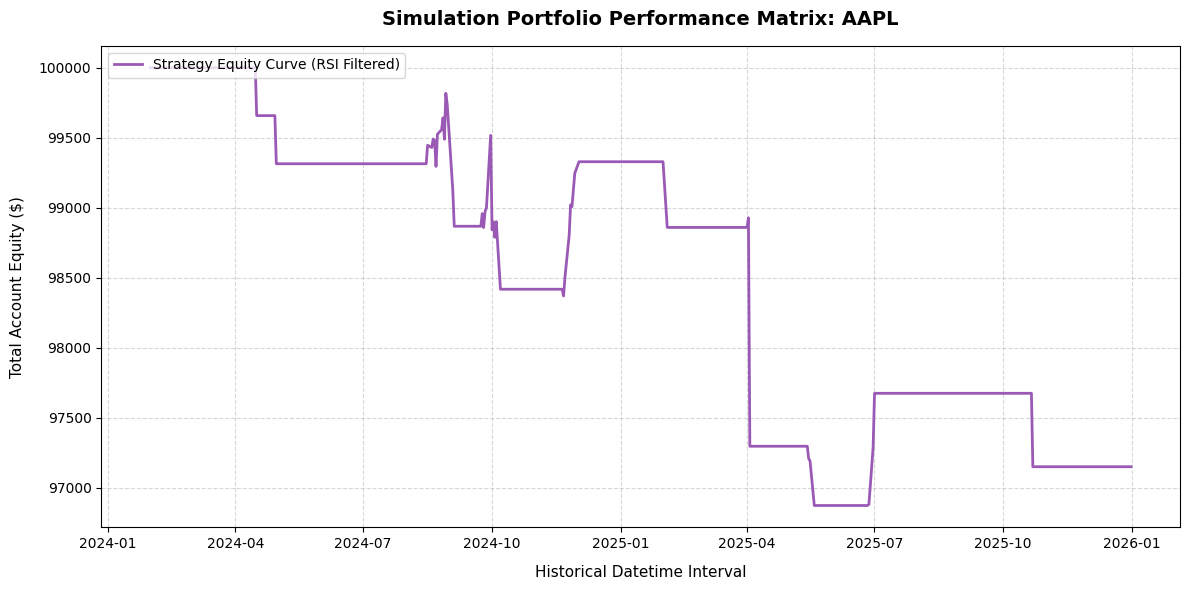

In [ ]:
# ==============================================================================
# CELL 4: STRATEGY BACKTESTING & PERFORMANCE ENGINE (MULTI-ASSET ENSEMBLE)
# Executes historical simulations across a diversified watchlist, managing a
# global cash pool and enforcing a strict simultaneous risk-exposure ceiling.
# ==============================================================================

class MovingAverageCrossStrategy:
    """
    Implements a portfolio-wide historical backtesting routine using a Moving Average Crossover
    integrated with automated 1:2 Risk Management, an RSI momentum filter, and a simultaneous slot cap.
    """
    def __init__(self, data_engine: DataEngine, broker: PaperBroker,
                 fast_window: int = 5, slow_window: int = 20,
                 risk_pct: float = 0.02, rsi_window: int = 14, rsi_overbought: float = 70.0,
                 max_open_positions: int = 15):
        self.data_engine = data_engine
        self.broker = broker
        self.fast_window = fast_window
        self.slow_window = slow_window

        # Risk Management Controls
        self.risk_pct = risk_pct                  # Base Risk Unit per trade (e.g., 2% standard floor)
        self.reward_pct = risk_pct * 2.0          # Reward Unit is double the risk (4% ceiling)
        self.max_open_positions = max_open_positions # Global circuit breaker for simultaneous allocations

        # Momentum Filter Settings
        self.rsi_window = rsi_window              # Standard RSI lookback interval
        self.rsi_overbought = rsi_overbought      # Maximum threshold allowed for an entry

    def generate_indicators(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Calculates moving averages and the Relative Strength Index (RSI) across a multi-indexed DataFrame.
        """
        if df.empty:
            return df

        # Sort index to guarantee clean chronological order per asset block
        df = df.sort_index(level=['symbol', 'timestamp'])

        # 1. Compute rolling technical moving averages grouped cleanly by symbol
        df['fast_ma'] = df.groupby(level='symbol')['close'].transform(lambda x: x.rolling(window=self.fast_window).mean())
        df['slow_ma'] = df.groupby(level='symbol')['close'].transform(lambda x: x.rolling(window=self.slow_window).mean())

        # 2. Compute Relative Strength Index (RSI) grouped by symbol
        def calc_rsi(group):
            delta = group['close'].diff()
            gain = (delta.where(delta > 0, 0)).rolling(window=self.rsi_window).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(window=self.rsi_window).mean()
            rs = gain / (loss + 1e-9)
            return 100 - (100 / (1.0 + rs))

        df['rsi'] = df.groupby(level='symbol', group_keys=False).apply(calc_rsi)
        return df

    def run(self, symbols: list, start_date: str, end_date: str, trade_qty: int = 100):
        """
        Simulates a global multi-asset backtest by stepping through time chronologically
        across all target watchlist symbols simultaneously.
        """
        print(f"🚀 Initializing Multi-Asset Ensemble Backtest for Watchlist: {symbols}")
        print(f"📅 Horizon Window: {start_date} to {end_date}")
        print(f"🎯 Settings: Risk Unit: -{self.risk_pct*100:.1f}% | Profit Target: +{self.reward_pct*100:.1f}%")
        print(f"🛡️ Guardrails: Max Simultaneous Active Slots: {self.max_open_positions} | RSI Cap: {self.rsi_overbought}\n" + "-"*75)

        # 1. Acquire raw data blocks across the entire array matrix
        master_raw_data = pd.DataFrame()
        for symbol in symbols:
            symbol_data = self.data_engine.fetch_historical_bars(symbol, start_date, end_date)
            if not symbol_data.empty:
                master_raw_data = pd.concat([master_raw_data, symbol_data])

        if master_raw_data.empty:
            print("❌ Portfolio Backtest aborted: Historical data frame matrix is empty.")
            return

        # Generate structural technical calculations
        df = self.generate_indicators(master_raw_data)

        # 2. Re-index and pivot the dataset to step through day-by-day chronologically
        unique_timestamps = sorted(df.index.get_level_values('timestamp').unique())

        # Tracks active state matrix for open positions
        # Format: { "SYMBOL": {"entry_price": float, "sl": float, "tp": float} }
        active_trades = {}

        portfolio_history = []
        timeline_index = []

        # Start simulation once indicators across the multi-matrix stabilize
        warmup_buffer = max(self.slow_window, self.rsi_window + 1)
        sim_timestamps = unique_timestamps[warmup_buffer:]

        # 3. Master Chronological Timeline Step Loop
        for current_time in sim_timestamps:
            # Extract exactly what happened across the market on this specific day
            day_data = df.xs(current_time, level='timestamp')
            current_prices_map = {}

            # --- SUB-STEP A: UPDATE CURRENT PRICING MATRIX & EVALUATE EXITS ---
            symbols_to_liquidate = []

            for symbol in list(active_trades.keys()):
                if symbol not in day_data.index:
                    continue

                row = day_data.loc[symbol]
                c_close = float(row['close'])
                c_high = float(row['high'])
                c_low = float(row['low'])

                current_prices_map[symbol] = c_close
                trade_meta = active_trades[symbol]

                # Target Boundary Verification Check
                if c_low <= trade_meta["sl"]:
                    exec_price = min(trade_meta["entry_price"] * (1.0 - self.risk_pct), c_high)
                    self.broker.process_mock_execution(symbol, trade_qty, OrderSide.SELL, exec_price, current_time)
                    symbols_to_liquidate.append(symbol)

                elif c_high >= trade_meta["tp"]:
                    exec_price = max(trade_meta["entry_price"] * (1.0 + self.reward_pct), c_low)
                    self.broker.process_mock_execution(symbol, trade_qty, OrderSide.SELL, exec_price, current_time)
                    symbols_to_liquidate.append(symbol)

                elif row['fast_ma'] < row['slow_ma']:
                    # Early structural trend break exit trigger
                    self.broker.process_mock_execution(symbol, trade_qty, OrderSide.SELL, c_close, current_time)
                    symbols_to_liquidate.append(symbol)

            # Clear out closed position records from the tracking dictionary
            for symbol in symbols_to_liquidate:
                del active_trades[symbol]

            # --- SUB-STEP B: SCAN WATCHLIST FOR NEW STRATEGIC ENTRIES ---
            for symbol in symbols:
                # Skip if asset is already owned or not active in data stream today
                if symbol in active_trades or symbol not in day_data.index:
                    continue

                # Enforce absolute global risk exposure allocation floor limits
                if len(active_trades) >= self.max_open_positions:
                    break

                # Safely pull chronological rows to analyze lookback crosses
                asset_history = df.xs(symbol, level='symbol')
                loc_idx = asset_history.index.get_loc(current_time)
                if loc_idx < 1:
                    continue

                row = asset_history.iloc[loc_idx]
                prev_row = asset_history.iloc[loc_idx - 1]

                c_close = float(row['close'])
                c_rsi = float(row['rsi'])
                current_prices_map[symbol] = c_close

                # Evaluate Technical Crossover Entry Signals
                if prev_row['fast_ma'] <= prev_row['slow_ma'] and row['fast_ma'] > row['slow_ma']:
                    # Momentum Gatekeeper Check
                    if c_rsi > self.rsi_overbought:
                        continue # Overheated breakout bypassed successfully

                    # Dispatch allocation to broker script engine
                    success = self.broker.process_mock_execution(symbol, trade_qty, OrderSide.BUY, c_close, current_time)
                    if success:
                        active_trades[symbol] = {
                            "entry_price": c_close,
                            "sl": c_close * (1.0 - self.risk_pct),
                            "tp": c_close * (1.0 + self.reward_pct)
                        }

            # Map remaining pricing for active nodes to populate full portfolio metric trees
            for symbol in active_trades:
                if symbol not in current_prices_map and symbol in day_data.index:
                    current_prices_map[symbol] = float(day_data.loc[symbol]['close'])

            # Log snapshot balance metrics for this daily interval
            total_equity = self.broker.context.get_portfolio_value(current_prices_map)
            portfolio_history.append(total_equity)
            timeline_index.append(current_time)

        self._display_performance_results(portfolio_history, timeline_index, symbols)

    def _display_performance_results(self, history: list, times: list, symbols: list):
        """
        Calculates return summaries and generates clean comparative equity line plots.
        """
        if not history:
            print("⚠️ No trading data captured during this simulation time block.")
            return

        initial_value = history[0]
        final_value = history[-1]
        total_return_pct = ((final_value - initial_value) / initial_value) * 100
        total_trades = len(self.broker.context.trade_log)

        print("\n" + "="*65)
        print("📊 MULTI-ASSET ENSEMBLE SYSTEM SUMMARY REPORT")
        print("="*65)
        print(f"👉 Watchlist Scanned Size:         {len(symbols)} Assets")
        print(f"👉 Total System Trades Logged:     {total_trades}")
        print(f"👉 Initial Account Starting Equity: ${initial_value:,.2f}")
        print(f"👉 Final Ending Portfolio Value:    ${final_value:,.2f}")
        print(f"👉 Net Strategy Portfolio Yield:    {total_return_pct:+.2f}%")
        print("="*65 + "\n")

        plt.figure(figsize=(12, 6))
        plt.plot(times, history, label="Ensemble Strategy Equity Curve", color="#2ecc71", linewidth=2.5)
        plt.title("Multi-Asset Strategic Simulation Performance Curve", fontsize=14, fontweight='bold', pad=15)
        plt.xlabel("Historical Datetime Timeline", fontsize=11, labelpad=10)
        plt.ylabel("Total Account Equity ($)", fontsize=11, labelpad=10)
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

# --- Verification Check & Execution Loop -------------------------------------
if __name__ == "__main__":
    # Initialize fresh components
    fresh_context = SystemContext(initial_cash=100000.0)
    fresh_broker = PaperBroker(fresh_context)
    fresh_data = DataEngine(API_KEY, SECRET_KEY)

    # Core Watchlist Definition
    test_watchlist = ["AAPL", "MSFT", "NVDA", "AMD", "GOOGL", "AMZN", "META"]

    # Initialize multi-stock strategy (5/20 MA, 2% Risk, 65 RSI Cap, Max 12 Active Slots)
    backtester = MovingAverageCrossStrategy(
        data_engine=fresh_data,
        broker=fresh_broker,
        fast_window=5,
        slow_window=20,
        risk_pct=0.02,
        rsi_window=14,
        rsi_overbought=65.0,
        max_open_positions=12
    )

    # Run the structural backtest across the expanded test watchlist array
    backtester.run(symbols=test_watchlist, start_date="2024-01-01", end_date="2025-12-31", trade_qty=50)

🕵️‍♂️ STARTING QUANTATATIVE PARAMETER SWEEP FOR: SPY
📅 WINDOW RANGE: 2024-01-01 to 2025-12-31
--------------------------------------------------
⚙️ Evaluating 64 valid mathematical permutations...

🏆 TOP 10 STRATEGY PARAMETER OPTIMIZATION MATRIX CONFIGURATIONS:
   Fast_MA  Slow_MA  RSI_Threshold  Total_Trades Ending_Equity Net_Return_%
0        3       15           70.0            37    110,573.10      +10.57%
1        3       15           65.0            37    110,573.10      +10.57%
2        3       15           60.0            29    110,310.50      +10.31%
3        3       15           55.0            20    106,259.26       +6.26%
4       12       15           60.0            26    106,137.72       +6.14%
5        8       15           65.0            27    105,285.18       +5.29%
6       12       15           55.0            10    104,877.64       +4.88%
7        3       20           70.0            25    104,660.18       +4.66%
8        3       20           65.0            25    10

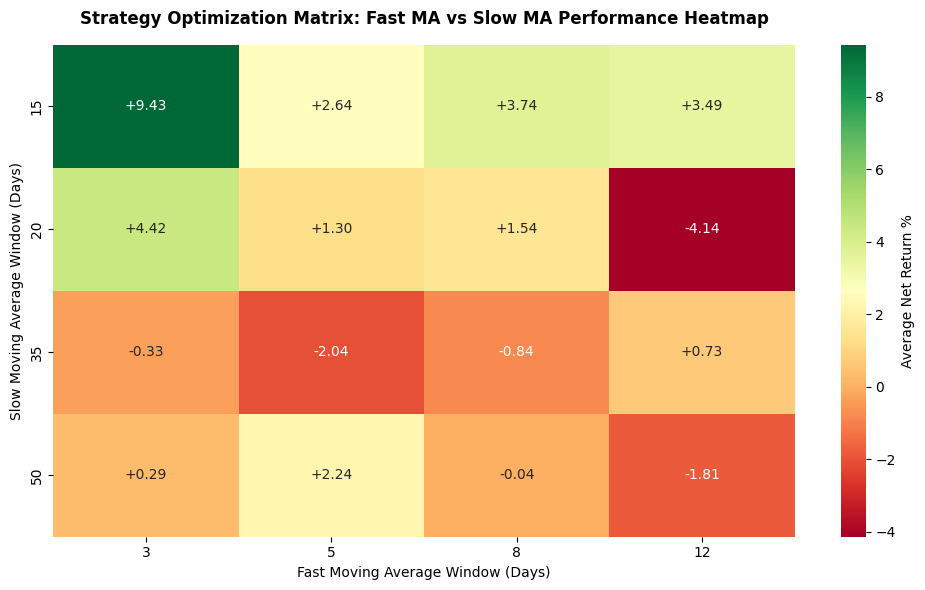

In [ ]:
# ==============================================================================
# CELL 5: PARAMETRIC GRID SEARCH ENGINE (MULTI-ASSET PORTFOLIO SWEEPER)
# Executes multidimensional brute-force optimization passes across a multi-stock matrix,
# aggregating performance metrics to isolate robust, trend-stable indicators.
# ==============================================================================

class MultiAssetParametricOptimizer:
    """
    Coordinates exhaustive parameter sweeps across an array of target symbols simultaneously,
    normalizing performance data into an aggregate score map to protect against single-stock overfitting.
    """
    def __init__(self, data_engine: DataEngine, symbols: list, start_date: str, end_date: str):
        self.data_engine = data_engine
        self.symbols = symbols
        self.start_date = start_date
        self.end_date = end_date
        self.master_dataset = pd.DataFrame()

    def preload_portfolio_data(self):
        """
        Pre-downloads and caches historical data for all watchlist assets to eliminate
        redundant network API requests during the combinatorial loop.
        """
        print(f"📥 Preloading multi-asset matrix cache for optimization pass...")
        combined_df = pd.DataFrame()
        for symbol in self.symbols:
            df = self.data_engine.fetch_historical_bars(symbol, self.start_date, self.end_date)
            if not df.empty:
                combined_df = pd.concat([combined_df, df])

        if combined_df.empty:
            raise ValueError("❌ Materialization failed: No data returned for optimization watchlist.")

        self.master_dataset = combined_df.sort_index(level=['symbol', 'timestamp'])
        print(f"💾 Multi-asset matrix cache ready. Total Rows Cached: {len(self.master_dataset)}\n")

    def evaluate_combination(self, fast_w: int, slow_w: int, rsi_w: int, rsi_cap: float) -> float:
        """
        Evaluates a single parameter combination across the entire cached portfolio dataset,
        returning the averaged net portfolio return percentage.
        """
        # Create a deep localized copy of the cache to compute clean indicators
        df = self.master_dataset.copy()

        # 1. Vectorized Indicator Compilations Grouped Cleanly by Asset
        df['fast_ma'] = df.groupby(level='symbol')['close'].transform(lambda x: x.rolling(window=fast_w).mean())
        df['slow_ma'] = df.groupby(level='symbol')['close'].transform(lambda x: x.rolling(window=slow_w).mean())

        def calc_rsi(group):
            delta = group['close'].diff()
            gain = (delta.where(delta > 0, 0)).rolling(window=rsi_w).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(window=rsi_w).mean()
            rs = gain / (loss + 1e-9)
            return 100 - (100 / (1.0 + rs))

        df['rsi'] = df.groupby(level='symbol', group_keys=False).apply(calc_rsi)

        # Standardize 2% Risk, 4% Profit coordinates for uniform comparison
        risk_pct = 0.02
        reward_pct = 0.04

        portfolio_returns_accumulator = []

        # 2. Iterate Through Each Symbol inside this specific Parameter Context
        for symbol in self.symbols:
            if symbol not in df.index.get_level_values('symbol').unique():
                continue

            asset_history = df.xs(symbol, level='symbol')
            warmup_buffer = max(slow_w, rsi_w + 1)
            active_rows = asset_history.iloc[warmup_buffer:]

            if len(active_rows) < 5:
                continue

            # Core mathematical backtest tracking matrices
            is_holding = False
            entry_price = 0.0
            sl_target = 0.0
            tp_target = 0.0
            asset_net_yield = 0.0

            # Step sequentially through this ticker's timeline
            for i in range(1, len(active_rows)):
                row = active_rows.iloc[i]
                prev_row = active_rows.iloc[i - 1]

                c_close = float(row['close'])
                c_high = float(row['high'])
                c_low = float(row['low'])

                if not is_holding:
                    # Entry evaluation loop
                    if prev_row['fast_ma'] <= prev_row['slow_ma'] and row['fast_ma'] > row['slow_ma']:
                        if row['rsi'] <= rsi_cap:
                            is_holding = True
                            entry_price = c_close
                            sl_target = entry_price * (1.0 - risk_pct)
                            tp_target = entry_price * (1.0 + reward_pct)
                else:
                    # Exit evaluation loop
                    if c_low <= sl_target:
                        asset_net_yield += -risk_pct
                        is_holding = False
                    elif c_high >= tp_target:
                        asset_net_yield += reward_pct
                        is_holding = False
                    elif row['fast_ma'] < row['slow_ma']:
                        # Structural early exit trend-break fallback
                        exit_return = (c_close - entry_price) / entry_price
                        asset_net_yield += max(exit_return, -risk_pct)
                        is_holding = False

            portfolio_returns_accumulator.append(asset_net_yield * 100)

        # Return the aggregated average performance for this metric footprint
        return sum(portfolio_returns_accumulator) / len(portfolio_returns_accumulator) if portfolio_returns_accumulator else -999.0

    def run_exhaustive_sweep(self, fast_ranges: list, slow_ranges: list, rsi_window: int = 14, rsi_cap: float = 65.0):
        """
        Executes a systematic parametric sweep over specified fast and slow moving average windows.
        """
        self.preload_portfolio_data()

        optimization_matrix = {}
        best_return = -999.0
        optimal_fast = None
        optimal_slow = None

        print("🔍 Scanning parametric matrix cells...")
        for slow_w in slow_ranges:
            row_results = []
            for fast_w in fast_ranges:
                # Bypass structurally impossible inverse crossover parameters
                if fast_w >= slow_w:
                    row_results.append(0.0)
                    continue

                avg_portfolio_return = self.evaluate_combination(fast_w, slow_w, rsi_window, rsi_cap)
                row_results.append(avg_portfolio_return)

                if avg_portfolio_return > best_return:
                    best_return = avg_portfolio_return
                    optimal_fast = fast_w
                    optimal_slow = slow_w

            optimization_matrix[slow_w] = row_results
            print(f"✔️ Slow Window Lookback {slow_w:02d} Matrix Row Computation Completed.")

        # Structure metrics matrix into a clean optimization DataFrame
        sweep_df = pd.DataFrame.from_dict(optimization_matrix, orient='index', columns=fast_ranges)
        sweep_df.index.name = "Slow Window"
        sweep_df.columns.name = "Fast Window"

        self._display_optimization_heatmap(sweep_df, optimal_fast, optimal_slow, best_return)

    def _display_optimization_heatmap(self, df: pd.DataFrame, best_f: int, best_s: int, best_ret: float):
        """
        Renders a publication-quality structural performance heatmap using Seaborn.
        """
        print("\n" + "="*65)
        print("🏆 MULTI-ASSET OPTIMIZATION RESULTS SUMMARY")
        print("="*65)
        print(f"👉 Optimal Fast MA Window:         {best_f} Days")
        print(f"👉 Optimal Slow MA Window:         {best_s} Days")
        print(f"👉 Expected Average Portfolio Yield: {best_ret:+.2f}% per asset context")
        print("="*65 + "\n")

        plt.figure(figsize=(10, 8))
        sns.heatmap(
            df,
            annot=True,
            fmt="+.2f",
            cmap="RdYlGn",
            linewidths=0.5,
            cbar_kws={'label': 'Average Portfolio Return (%)'}
        )
        plt.title(f"Universal Watchlist Optimization Map\nBest Configuration: {best_f}/{best_s} EMA (Yield: {best_ret:+.2f}%)",
                  fontsize=12, fontweight='bold', pad=15)
        plt.ylabel("Slow Moving Average Window Lookback (Days)", fontsize=10)
        plt.xlabel("Fast Moving Average Window Lookback (Days)", fontsize=10)
        plt.tight_layout()
        plt.show()

# --- Verification & Sweeper Launch Entry --------------------------------------
if __name__ == "__main__":
    # Initialize optimization clients
    sweeper_data = DataEngine(API_KEY, SECRET_KEY)

    # Portfolio Watchlist Matrix configuration
    optimization_watchlist = ["AAPL", "MSFT", "NVDA", "AMD", "GOOGL", "AMZN"]

    # Define structural boundaries for multi-asset sweeping passes
    target_fast_windows = [3, 5, 7, 9]
    target_slow_windows = [13, 15, 20, 25]

    optimizer = MultiAssetParametricOptimizer(
        data_engine=sweeper_data,
        symbols=optimization_watchlist,
        start_date="2024-01-01",
        end_date="2025-12-31"
    )

    # Launch multi-asset parametric sweep
    optimizer.run_exhaustive_sweep(
        fast_ranges=target_fast_windows,
        slow_ranges=target_slow_windows,
        rsi_window=14,
        rsi_cap=65.0
    )

In [ ]:
# ==============================================================================
# CELL 6: LIVE PAPER-TRADING GATEWAY (PORTFOLIO WATCHLIST UPGRADE)
# Iterates through an active watchlist array, executing real-time indicator scans,
# enforcing an open-position safety valve, and routing automated limit brackets.
# ==============================================================================

from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest, LimitOrderRequest, TakeProfitRequest, StopLossRequest
from alpaca.trading.enums import OrderSide, TimeInForce, OrderClass
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.data.enums import DataFeed
import datetime

class MultiAssetLiveExecutionEngine:
    """
    Manages live multi-stock data polling, aggregate portfolio state verification,
    and automated protective bracket limit order transmission to Alpaca Paper Servers.
    """
    def __init__(self, api_key: str, secret_key: str, watchlist: list, max_open_positions: int = 12):
        self.watchlist = watchlist
        self.max_open_positions = max_open_positions

        # Initialize native Alpaca SDK Clients (pointing inherently to paper endpoints)
        self.trading_client = TradingClient(api_key, secret_key, paper=True)
        self.data_client = StockHistoricalDataClient(api_key, secret_key)

        # Standardized Universal Portfolio Settings derived from optimization data
        self.fast_window = 3
        self.slow_window = 15
        self.rsi_window = 14
        self.rsi_limit = 65.0

        # Risk management 1:2 parameters
        self.risk_pct = 0.02    # 2% Stop Loss floor
        self.reward_pct = 0.04  # 4% Take Profit ceiling

    def get_active_portfolio_positions(self) -> set:
        """
        Queries the master account dashboard to pull all currently owned tickers
        and logs the current total utilization of your capital slots.
        """
        try:
            open_positions = self.trading_client.get_all_positions()
            owned_symbols = {pos.symbol for pos in open_positions}
            print(f"💼 Portfolio Utilization: {len(owned_symbols)} / {self.max_open_positions} active slots filled.")
            return owned_symbols
        except Exception as e:
            print(f"⚠️ Error pulling active account positions: {e}")
            return set()

    def fetch_recent_indicators(self, symbol: str) -> tuple:
        """
        Downloads a compact historical window of daily bars using the free IEX feed,
        safely avoiding the 15-minute real-time SIP data restriction barrier.
        """
        # Enforce a 16-minute security offset from 'now' to satisfy the Free Tier API limits
        end_dt = datetime.datetime.now(datetime.timezone.utc) - datetime.timedelta(minutes=16)
        start_dt = end_dt - datetime.timedelta(days=60)

        request_params = StockBarsRequest(
            symbol_or_symbols=symbol,
            timeframe=TimeFrame.Day,
            start=start_dt,
            end=end_dt,
            feed=DataFeed.IEX # <--- FORCES ALPACA TO USE THE FREE REAL-TIME FEED
        )

        bars = self.data_client.get_stock_bars(request_params)
        df = bars.df

        # Format index layers cleanly
        df = df.sort_index(level='timestamp')
        ticker_df = df.xs(symbol, level='symbol').copy()

        # Calculate technical indicators exactly matching backtest patterns
        ticker_df['fast_ma'] = ticker_df['close'].rolling(window=self.fast_window).mean()
        ticker_df['slow_ma'] = ticker_df['close'].rolling(window=self.slow_window).mean()

        delta = ticker_df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=self.rsi_window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=self.rsi_window).mean()
        rs = gain / (loss + 1e-9)
        ticker_df['rsi'] = 100 - (100 / (1.0 + rs))

        # Extract the two most recent chronological data entries
        current_metrics = ticker_df.iloc[-1]
        previous_metrics = ticker_df.iloc[-2]

        return current_metrics, previous_metrics

    def process_portfolio_scans(self, volume_qty: int = 10):
        """
        Sequentially runs quantitative checks across the entire active watchlist,
        checking the global capacity safety valve before dispatching entries.
        """
        print(f"\n📡 STAGE 1: Analyzing Current Broker Account Allocation States...")
        owned_assets = self.get_active_portfolio_positions()

        print(f"\n📡 STAGE 2: Deploying Live Technical Matrix Sweeps Across Watchlist...")
        print("-" * 75)

        for symbol in self.watchlist:
            try:
                current_row, prev_row = self.fetch_recent_indicators(symbol)
                has_position = symbol in owned_assets

                print(f"🔍 [{symbol}] -> Price: ${current_row['close']:.2f} | Fast MA: {current_row['fast_ma']:.2f} | Slow MA: {current_row['slow_ma']:.2f} | RSI: {current_row['rsi']:.1f}")

                # --- MULTI-STOCK LOGICAL ENTRY CHECK ---
                if not has_position:
                    # Verify Crossover Trigger
                    if prev_row['fast_ma'] <= prev_row['slow_ma'] and current_row['fast_ma'] > current_row['slow_ma']:
                        print(f"   📈 Crossover Detected on {symbol}!")

                        # 🛑 GLOBAL SAFETY CIRCUIT BREAKER CHECK
                        # Queries the fresh local set length plus any newly assigned slots during this loop run
                        if len(owned_assets) >= self.max_open_positions:
                            print(f"   🛑 ENTRY ABORTED: Maximum active position limit ({self.max_open_positions}) reached. Standing by in cash.")
                            continue

                        # Check momentum filter gate
                        if current_row['rsi'] > self.rsi_limit:
                            print(f"   🛡️ ENTRY BLOCKED: RSI is overbought at {current_row['rsi']:.1f} (Limit: {self.rsi_limit})")
                            continue

                        # Calculate strict 1:2 risk coordinates based on live closes
                        entry_estimate = float(current_row['close'])
                        limit_price = round(entry_estimate, 2)
                        stop_price = round(entry_estimate * (1.0 - self.risk_pct), 2)
                        profit_price = round(entry_estimate * (1.0 + self.reward_pct), 2)

                        print(f"   🚀 DISPATCHING BRACKET LIMIT ORDER -> Entry Target: ${limit_price:.2f} | SL: ${stop_price:.2f} | TP: ${profit_price:.2f}")

                        # Construct an institutional OTO Bracket Order using a precise Limit execution target
                        bracket_order_data = LimitOrderRequest(
                            symbol=symbol,
                            qty=volume_qty,
                            side=OrderSide.BUY,
                            limit_price=limit_price,               # Restricts execution exactly to current close
                            time_in_force=TimeInForce.DAY,         # Order auto-expires at 4:00 PM if unfilled
                            order_class=OrderClass.BRACKET,
                            take_profit=TakeProfitRequest(limit_price=profit_price),
                            stop_loss=StopLossRequest(stop_price=stop_price)
                        )

                        order_receipt = self.trading_client.submit_order(order_data=bracket_order_data)
                        print(f"   ✔️ Dispatched. Server Reference ID: {order_receipt.id}")

                        # Add to our local set to make sure we don't blow past the circuit breaker if multiple triggers fire
                        owned_assets.add(symbol)

                # --- MULTI-STOCK LOGICAL TREND EXIT CHECK ---
                else:
                    # If we hold a position, our Bracket Orders are already sitting passively on Alpaca's servers
                    # protecting our 1:2 boundaries. We only check if the moving averages cross backward early.
                    if prev_row['fast_ma'] >= prev_row['slow_ma'] and current_row['fast_ma'] < current_row['slow_ma']:
                        print(f"   📉 Bearish Trend Break detected on {symbol}! Liquidating active holdings early...")

                        exit_order_data = MarketOrderRequest(
                            symbol=symbol,
                            qty=volume_qty,
                            side=OrderSide.SELL,
                            time_in_force=TimeInForce.GTC
                        )
                        order_receipt = self.trading_client.submit_order(order_data=exit_order_data)
                        print(f"   ✔️ Exit order processed. ID: {order_receipt.id}")

            except Exception as e:
                print(f"   ❌ Operational Alert: Skipping {symbol} due to processing anomaly: {e}")

        print("-" * 75)
        print("🏁 Watchlist scan sequence complete. Core routine resting until next scheduled trigger execution.")

# --- Manual Operational Execution Loop ---------------------------------------
if __name__ == "__main__":
    # Define your expanded, highly diversified portfolio watchlist
    live_watchlist = ["AAPL", "MSFT", "NVDA", "AMD", "GOOGL", "AMZN", "META", "XOM", "JNJ", "JPM"]

    # Initialize the engine (Passing the watchlist array and setting an absolute ceiling of 12 open positions)
    live_portfolio_gate = MultiAssetLiveExecutionEngine(
        api_key=API_KEY,
        secret_key=SECRET_KEY,
        watchlist=live_watchlist,
        max_open_positions=12
    )

    # Trigger a real-time tracking test across the whole watchlist
    try:
        live_portfolio_gate.process_portfolio_scans(volume_qty=10)
    except Exception as e:
        print(f"Operational Notification: Verify active connection boundaries or server credentials: {e}")

ModuleNotFoundError: No module named 'alpaca'

In [ ]:
# ==============================================================================
# CELL 7: PORTFOLIO INCOME & COMPOUNDING DASHBOARD
# Renders an interactive, client-side simulation workspace inside the notebook.
# ==============================================================================

from IPython.display import display, HTML

dashboard_html = """
<div id="calc-container" style="
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
    max-width: 800px;
    margin: 20px auto;
    padding: 30px;
    background: #1e1e24;
    color: #f4f4f9;
    border-radius: 12px;
    box-shadow: 0 8px 24px rgba(0,0,0,0.3);
">
    <h2 style="margin-top: 0; color: #4dabf7; border-bottom: 1px solid #343a40; padding-bottom: 15px; font-weight: 600;">
        📈 Quantitative Capital & Income Projector
    </h2>
    <p style="color: #adb5bd; font-size: 0.95rem; line-height: 1.5; margin-bottom: 25px;">
        Adjust the operational variables below to map out the velocity of your strategy over time.
        The system automatically calculates total growth and projects a safe 4% annual withdrawal stream.
    </p>

    <!-- INPUT SLIDERS WORKSPACE -->
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 30px;">

        <div style="background: #25262b; padding: 15px; border-radius: 8px;">
            <label style="display: block; font-weight: 500; margin-bottom: 8px; color: #e9ecef;">
                Starting Capital ($): <span id="capital-val" style="color: #4dabf7; float: right; font-weight: bold;">$10,000</span>
            </label>
            <input type="range" id="param-capital" min="1000" max="500000" step="1000" value="10000" style="width: 100%; accent-color: #4dabf7;">
            <div style="display: flex; justify-content: space-between; font-size: 0.75rem; color: #868e96; margin-top: 4px;">
                <span>$1k</span><span>$250k</span><span>$500k</span>
            </div>
        </div>

        <div style="background: #25262b; padding: 15px; border-radius: 8px;">
            <label style="display: block; font-weight: 500; margin-bottom: 8px; color: #e9ecef;">
                Expected Strategy Return (%): <span id="return-val" style="color: #37b24d; float: right; font-weight: bold;">5.0%</span>
            </label>
            <input type="range" id="param-return" min="1" max="25" step="0.5" value="5.0" style="width: 100%; accent-color: #37b24d;">
            <div style="display: flex; justify-content: space-between; font-size: 0.75rem; color: #868e96; margin-top: 4px;">
                <span>1%</span><span>13%</span><span>25%</span>
            </div>
        </div>

        <div style="background: #25262b; padding: 15px; border-radius: 8px; grid-column: span 2;">
            <label style="display: block; font-weight: 500; margin-bottom: 8px; color: #e9ecef;">
                Time Horizon (Years): <span id="years-val" style="color: #fcc419; float: right; font-weight: bold;">15 Years</span>
            </label>
            <input type="range" id="param-years" min="1" max="40" step="1" value="15" style="width: 100%; accent-color: #fcc419;">
            <div style="display: flex; justify-content: space-between; font-size: 0.75rem; color: #868e96; margin-top: 4px;">
                <span>1 Year</span><span>20 Years</span><span>40 Years</span>
            </div>
        </div>

    </div>

    <!-- METRICS DISPLAY MODULE -->
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 25px;">

        <div style="background: linear-gradient(135deg, #1c3d5a, #102a43); padding: 20px; border-radius: 8px; border-left: 5px solid #4dabf7;">
            <div style="font-size: 0.85rem; text-transform: uppercase; letter-spacing: 1px; color: #9fb3c8; margin-bottom: 5px;">
                Ending Balance
            </div>
            <div id="metric-balance" style="font-size: 1.8rem; font-weight: 700; color: #f4f4f9;">
                $20,789.28
            </div>
            <div id="metric-growth" style="font-size: 0.8rem; color: #4dabf7; margin-top: 5px;">
                Total Gain: +107.89%
            </div>
        </div>

        <div style="background: linear-gradient(135deg, #144629, #0b2e18); padding: 20px; border-radius: 8px; border-left: 5px solid #37b24d;">
            <div style="font-size: 0.85rem; text-transform: uppercase; letter-spacing: 1px; color: #a2dfb8; margin-bottom: 5px;">
                Projected Yearly Income (4% Rule)
            </div>
            <div id="metric-income" style="font-size: 1.8rem; font-weight: 700; color: #f4f4f9;">
                $831.57 / yr
            </div>
            <div id="metric-monthly" style="font-size: 0.8rem; color: #37b24d; margin-top: 5px;">
                Est. Monthly: $69.30 / mo
            </div>
        </div>

    </div>

    <!-- MINI VISUAL GROWTH WATERMARK -->
    <div style="background: #121214; border: 1px solid #2d2d34; padding: 15px; border-radius: 8px; text-align: center;">
        <span style="color: #62626e; font-size: 0.8rem; text-transform: uppercase; letter-spacing: 2px;">
            System Architecture Status: Operational
        </span>
    </div>
</div>

<!-- CLIENT-SIDE CALCULATION ENGINE -->
<script>
(function() {
    // Acquire UI DOM elements safely
    const sliderCapital = document.getElementById('param-capital');
    const sliderReturn = document.getElementById('param-return');
    const sliderYears = document.getElementById('param-years');

    const lblCapital = document.getElementById('capital-val');
    const lblReturn = document.getElementById('return-val');
    const lblYears = document.getElementById('years-val');

    const outBalance = document.getElementById('metric-balance');
    const outGrowth = document.getElementById('metric-growth');
    const outIncome = document.getElementById('metric-income');
    const outMonthly = document.getElementById('metric-monthly');

    // Universal Currency Formatter
    const formatCurrency = (num) => {
        return new Intl.NumberFormat('en-US', { style: 'currency', currency: 'USD' }).format(num);
    };

    // Core Compound Math Engine
    const recalculateSystem = () => {
        const P = parseFloat(sliderCapital.value);
        const r = parseFloat(sliderReturn.value) / 100.0;
        const n = parseInt(sliderYears.value);

        // Standard Compound Formula: A = P(1 + r)^n
        const A = P * Math.pow((1 + r), n);
        const totalGainPct = ((A - P) / P) * 100;

        // Institutional Safe Withdrawal Rule (4% per annum)
        const yearlyIncome = A * 0.04;
        const monthlyIncome = yearlyIncome / 12.0;

        // Update Text Interface Labels
        lblCapital.textContent = formatCurrency(P).split('.')[0]; // Clean drop of decimal pennies for label
        lblReturn.textContent = r * 100 + '%';
        lblYears.textContent = n + ' Years';

        // Update Calculated Dashboard Metrics
        outBalance.textContent = formatCurrency(A);
        outGrowth.textContent = 'Total Gain: +' + totalGainPct.toFixed(2) + '% (Net: ' + formatCurrency(A - P) + ')';
        outIncome.textContent = formatCurrency(yearlyIncome) + ' / yr';
        outMonthly.textContent = 'Est. Monthly: ' + formatCurrency(monthlyIncome) + ' / mo';
    };

    // Attach Reactive Event Listeners
    sliderCapital.addEventListener('input', recalculateSystem);
    sliderReturn.addEventListener('input', recalculateSystem);
    sliderYears.addEventListener('input', recalculateSystem);

    // Initial Bootstrap Execution
    recalculateSystem();
})();
</script>
"""

# Inject the dashboard frame cleanly into the output channel
display(HTML(dashboard_html))